#### (번외)불량 유형별 예측

In [61]:
# y: Defects 그룹 전체 (멀티라벨)
#y_cols = [c for c in df.columns if c[0] == 'Defects']
#y = df[y_cols].astype(int)

# X: Process + Sensor 
#X = df[[c for c in df.columns if c[0] in ('Process', 'Sensor')]].copy()
#X = X.drop(columns=[('Process', 'id')], errors='ignore')
#X = X.drop(columns=[('Process', 'Product_Type')], errors='ignore')

#print("X:", X.shape, "y:", y.shape)
#print("y columns (first 10):", y.columns[:10].tolist())

# 환경설정하기

In [62]:
# 라이브러리 Import
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import warnings

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, confusion_matrix, classification_report,
                             roc_auc_score, roc_curve)
import xgboost as xgb

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# 한글 폰트 설정
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)

np.random.seed(42)

print("="*60)
print("라이브러리 로드 완료!")
print("="*60)


라이브러리 로드 완료!


### 데이터 로드

In [63]:
df1 = pd.read_csv("../../data/product_type_1.csv", header=[0, 1])
df = df1.copy()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2653 entries, 0 to 2652
Data columns (total 42 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   (process, id)                   2653 non-null   int64  
 1   (process, product_type)         2653 non-null   int64  
 2   (process, shot)                 2653 non-null   int64  
 3   (process, velocity_1)           2653 non-null   float64
 4   (process, velocity_2)           2653 non-null   float64
 5   (process, velocity_3)           2653 non-null   float64
 6   (process, high_velocity)        2653 non-null   float64
 7   (process, cylinder_pressure)    2653 non-null   int64  
 8   (process, rapid_rise_time)      2653 non-null   float64
 9   (process, biscuit_thickness)    2653 non-null   int64  
 10  (process, clamping_force)       2653 non-null   int64  
 11  (process, cycle_time)           2653 non-null   float64
 12  (process, pressure_rise_time)   2653 non-null

In [64]:
print("="*60)
print("남은 defects 컬럼 확인")
print("="*60)

df[[c for c in df.columns if c[0] == 'defects']].info()

남은 defects 컬럼 확인
<class 'pandas.DataFrame'>
RangeIndex: 2653 entries, 0 to 2652
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   (defects, short_shot_1)   2653 non-null   int64
 1   (defects, bubble_1)       2653 non-null   int64
 2   (defects, exfoliation_1)  2653 non-null   int64
 3   (defects, stain_1)        2653 non-null   int64
 4   (defects, dent_1)         2653 non-null   int64
 5   (defects, deformation_1)  2653 non-null   int64
 6   (defects, short_shot_2)   2653 non-null   int64
 7   (defects, bubble_2)       2653 non-null   int64
 8   (defects, exfoliation_2)  2653 non-null   int64
 9   (defects, deformation_2)  2653 non-null   int64
dtypes: int64(10)
memory usage: 207.4 KB


In [65]:
df['defects'].sum().sort_values(ascending=False)

exfoliation_1    124
short_shot_1     108
deformation_1    108
exfoliation_2     86
deformation_2     64
bubble_1          60
short_shot_2      60
bubble_2           5
dent_1             3
stain_1            3
dtype: int64

In [66]:
defect_groups = {
    "표면": [
        "dent_1",
        "stain_1",
        "exfoliation_1",
        "exfoliation_2"
    ],

    "구조": [
        "short_shot_1",
        "short_shot_2",
        "bubble_1",
        "bubble_2",
        "deformation_1",
        "deformation_2"
    ]
}

In [67]:

defects = df['defects'].copy()  # columns: Short_Shot_1, Blow_Hole_2, ...

# 각 범주별로 해당하는 defect 컬럼들을 찾아서 "하나라도 1이면 1"로 만들기
y_group = pd.DataFrame(index=df.index)

for group_name, base_names in defect_groups.items():
    # base_names 중 하나로 시작하는 컬럼들 찾기 (예: "Short_Shot" -> "Short_Shot_1", "Short_Shot_2")
    cols = [c for c in defects.columns if any(str(c).startswith(b) for b in base_names)]
    
    if len(cols) == 0:
        # 해당 범주에 매칭되는 컬럼이 없으면 0으로
        y_group[group_name] = 0
    else:
        y_group[group_name] = (defects[cols].fillna(0).astype(int).sum(axis=1) > 0).astype(int)

print(y_group.sum().sort_values(ascending=False))   # 범주별 발생 건수 확인
print(y_group.mean().mul(100))                      # 범주별 발생률(%) 확인

구조    387
표면    208
dtype: int64
표면     7.840181
구조    14.587260
dtype: float64


#### 불량 여부 이진 분류

### 타겟 | ('Defect_Flag','Is_Defect')

In [68]:
print("결측치 상위:\n", df.isnull().sum().sort_values(ascending=False).head(10))

print("\n불량 비율:\n", df[('defect_flag','is_defect')].value_counts(normalize=True))

결측치 상위:
 process  id                   0
         product_type         0
         shot                 0
         velocity_1           0
         velocity_2           0
         velocity_3           0
         high_velocity        0
         cylinder_pressure    0
         rapid_rise_time      0
         biscuit_thickness    0
dtype: int64

불량 비율:
 (defect_flag, is_defect)
0    0.782887
1    0.217113
Name: proportion, dtype: float64


# Train/Test split

#### XGBoost 사용을 위해 y는 멀티라벨 문제를 제거하는 방향. 
#### 0, 1, 2, 3으로 설정(한 샘플이 표면=1 and/or 구조=1 이 될 수 있음 (멀티라벨) 또는 동시에 0,0 (정상)일 수도 있음) 

In [69]:
((y_group["표면"]==1) & (y_group["구조"]==1)).sum()

np.int64(19)

In [70]:
import re

X = df[['process', 'sensor']].copy()
X = X.drop(columns=[
    ('process', 'id'),
    ('process', 'product_type')
])

# MultiIndex -> 단일 문자열 컬럼명으로 변환
X.columns = [
    f"{lvl0}_{lvl1}" for lvl0, lvl1 in X.columns
]

# 혹시 모를 특수문자 제거
X.columns = [
    re.sub(r"[^A-Za-z0-9_]+", "_", col) for col in X.columns
]
y = pd.Series(np.select(
    [
        (y_group["표면"]==0) & (y_group["구조"]==0),  # 정상
        (y_group["표면"]==1) & (y_group["구조"]==0),  # 표면만
        (y_group["표면"]==0) & (y_group["구조"]==1),  # 구조만
        (y_group["표면"]==1) & (y_group["구조"]==1),  # 복합
    ],
    [0, 1, 2, 3],
    default=0
), name="defect_class")


from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("train:", X_train.shape)
print("test:", X_test.shape)
print("")

print("train 불량률:", y_train.mean())
print("")
print("test 불량률:", y_test.mean())

print("")
print("="*60)
print(f"데이터 분포 유지됨")

print(f"랜덤 split이 잘 됨")

print(f"모델 평가 신뢰도 높음")
print("="*60)


train: (2122, 29)
test: (531, 29)

train 불량률: 0.3704052780395853

test 불량률: 0.3691148775894539

데이터 분포 유지됨
랜덤 split이 잘 됨
모델 평가 신뢰도 높음


# =================================================
# 여기까지 보시면 됩니다!
# =================================================

In [71]:
!pip install catboost
!pip install lightgbm
!pip install plotly.express


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [72]:


from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.datasets import load_wine
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.metrics import accuracy_score, classification_report
import plotly.express as px

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    "GBM": GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, max_depth=3, random_state=42),
    "XGBoost": XGBClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=4,
        subsample=0.9, colsample_bytree=0.9,
        objective="multi:softprob", num_class=y.nunique(),
        eval_metric="mlogloss", random_state=42
    ),
    "LightGBM": LGBMClassifier(n_estimators=300, learning_rate=0.05, num_leaves=31, random_state=42, verbose=-1),
    "CatBoost": CatBoostClassifier(iterations=300, learning_rate=0.05, depth=6, random_seed=42, verbose=0),
}

results = []
for name, model in models.items():
    cv_scores = cross_val_score(model, X, y, cv=cv, scoring="accuracy", n_jobs=-1)
    model.fit(X_train, y_train)
    test_acc = accuracy_score(y_test, model.predict(X_test))
    results.append({"Model": name, "CV mean": cv_scores.mean(), "CV std": cv_scores.std(), "Test Acc": test_acc})



df_compare = pd.DataFrame(results).sort_values("Test Acc", ascending=False)
display(df_compare)

fig = px.bar(
    df_compare, x="Model", y="Test Acc",
    text="Test Acc",
    title="Boosting 4종 비교 — Test Accuracy (Wine)",
    template="plotly_dark"
)
fig.update_traces(texttemplate="%{text:.3f}", textposition="outside")
fig.update_layout(yaxis=dict(range=[0.85, 1.02]))
fig.show()

,Model,CV mean,CV std,Test Acc
1,XGBoost,0.775725,0.003773,0.785311
3,CatBoost,0.787029,0.005503,0.783427
0,GBM,0.766677,0.010870,0.775895
2,LightGBM,0.754617,0.008109,0.758945


In [73]:
print(y.value_counts())
print(y.value_counts(normalize=True).sort_index())

defect_class
0    2077
2     368
1     189
3      19
Name: count, dtype: int64
defect_class
0    0.782887
1    0.071240
2    0.138711
3    0.007162
Name: proportion, dtype: float64


In [74]:
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import cross_val_score

dummy = DummyClassifier(strategy="most_frequent")
dummy_scores = cross_val_score(dummy, X, y, cv=cv, scoring="accuracy")

print("Dummy CV mean:", dummy_scores.mean())

Dummy CV mean: 0.7828873965106776


In [75]:
from sklearn.model_selection import cross_validate
from sklearn.metrics import f1_score

cv_result = cross_validate(
    model, X, y, cv=cv,
    scoring=["accuracy", "f1_macro", "f1_weighted"],
    n_jobs=-1
)

In [76]:
y_pred = model.predict(X_test)

from sklearn.metrics import accuracy_score, f1_score
print("Acc:", accuracy_score(y_test, y_pred))
print("F1-macro:", f1_score(y_test, y_pred, average="macro"))
print("F1-weighted:", f1_score(y_test, y_pred, average="weighted"))

Acc: 0.783427495291902
F1-macro: 0.24899286691059613
F1-weighted: 0.7060241867851414


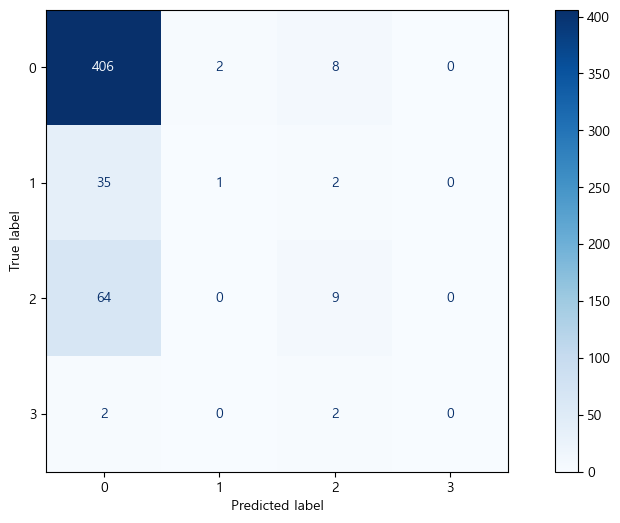

In [78]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

best_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=3,
    eval_metric="mlogloss",
    random_state=42
)

best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.show()

In [79]:
cv_scores = cross_val_score(
    model, X, y, cv=cv, scoring="accuracy",
    n_jobs=-1, error_score="raise"
)

## =========================

## class weight 적용

In [81]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train)
weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weight_dict = dict(zip(classes, weights))

In [82]:
XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    objective="multi:softprob",
    num_class=4,
)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

## SMOTE (데이터 균형 맞추기)

In [80]:
print("결측치 개수 합계:", X_train.isnull().sum().sum()) # train_set.isnull().sum().sum()

print("="*60)
print("결측치 없음!")
print("="*60)

결측치 개수 합계: 0
결측치 없음!


In [ ]:
X_train.dtypes

process  shot                      int64
         velocity_1              float64
         velocity_2              float64
         velocity_3              float64
         high_velocity           float64
         cylinder_pressure         int64
         rapid_rise_time         float64
         biscuit_thickness         int64
         clamping_force            int64
         cycle_time              float64
         pressure_rise_time      float64
         casting_pressure          int64
         spray_time              float64
         spray_1_time            float64
         spray_2_time            float64
sensor   melting_furnace_temp    float64
         air_pressure            float64
         air_pressure_min          int64
         air_pressure_max          int64
         coolant_temp            float64
         coolant_temp_min          int64
         coolant_temp_max          int64
         coolant_pressure        float64
         factory_temp            float64
         factory

## X Train data 정보 확인

In [ ]:
print(X_train.shape)
print(X_train.info())


(2122, 29)
<class 'pandas.DataFrame'>
Index: 2122 entries, 2605 to 1951
Data columns (total 29 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   (process, shot)                 2122 non-null   int64  
 1   (process, velocity_1)           2122 non-null   float64
 2   (process, velocity_2)           2122 non-null   float64
 3   (process, velocity_3)           2122 non-null   float64
 4   (process, high_velocity)        2122 non-null   float64
 5   (process, cylinder_pressure)    2122 non-null   int64  
 6   (process, rapid_rise_time)      2122 non-null   float64
 7   (process, biscuit_thickness)    2122 non-null   int64  
 8   (process, clamping_force)       2122 non-null   int64  
 9   (process, cycle_time)           2122 non-null   float64
 10  (process, pressure_rise_time)   2122 non-null   float64
 11  (process, casting_pressure)     2122 non-null   int64  
 12  (process, spray_time)           2122

In [ ]:
display(X_train.describe())

process                                                       \
              shot   velocity_1   velocity_2   velocity_3 high_velocity   
count  2122.000000  2122.000000  2122.000000  2122.000000   2122.000000   
mean    546.712535     0.143169     0.168772     0.182221      2.135822   
std     355.878437     0.003813     0.004659     0.006360      0.077480   
min       1.000000     0.136000     0.162000     0.172000      0.000000   
25%     231.000000     0.142000     0.168000     0.178000      2.122000   
50%     520.500000     0.142000     0.168000     0.182000      2.137000   
75%     842.000000     0.144000     0.170000     0.186000      2.153000   
max    1296.000000     0.180000     0.212000     0.234000      2.285000   

                                                                          \
      cylinder_pressure rapid_rise_time biscuit_thickness clamping_force   
count       2122.000000     2122.000000       2122.000000    2122.000000   
mean         218.917059        0.008053         11.655985     256.031574   
std            8.106359        0.001494          1.338663       2.241321   
min          107.000000        0.000000          0.000000     238.000000   
25%          215.000000        0.008000         11.000000     254.000000   
50%          217.000000        0.008000         12.000000     257.000000   
75%          218.000000        0.008000         12.000000     258.000000   
max          241.000000        0.021000         21.000000     263.000000   

                                                                     \
        cycle_time pressure_rise_time casting_pressure   spray_time   
count  2122.000000        2122.000000      2122.000000  2122.000000   
mean     21.363525           0.041779      1059.539114     8.235768   
std       6.465219           0.003088        39.123996     0.581206   
min      20.300000           0.000000       516.000000     7.000000   
25%      20.700000           0.041000      1039.000000     7.900000   
50%      20.900000           0.043000      1052.000000     8.000000   
75%      21.100000           0.044000      1055.000000     8.300000   
max     218.600000           0.046000      1164.000000    10.800000   

                                              sensor               \
      spray_1_time spray_2_time melting_furnace_temp air_pressure   
count  2122.000000  2122.000000          2122.000000  2122.000000   
mean      0.931810     0.790104           699.735297     6.128558   
std       0.145469     0.044352            13.610629     0.579392   
min       0.700000     0.700000           671.000000     4.600000   
25%       0.800000     0.800000           689.500000     5.800000   
50%       1.000000     0.800000           700.500000     6.200000   
75%       1.000000     0.800000           709.000000     6.600000   
max       1.200000     1.000000           730.000000     7.100000   

                                                                       \
      air_pressure_min air_pressure_max coolant_temp coolant_temp_min   
count           2122.0           2122.0  2122.000000           2122.0   
mean               3.0              9.0    26.762771             10.0   
std                0.0              0.0     0.471417              0.0   
min                3.0              9.0    25.900000             10.0   
25%                3.0              9.0    26.400000             10.0   
50%                3.0              9.0    26.800000             10.0   
75%                3.0              9.0    27.100000             10.0   
max                3.0              9.0    28.100000             10.0   

                                                                       \
      coolant_temp_max coolant_pressure factory_temp factory_temp_min   
count           2122.0      2122.000000  2122.000000           2122.0   
mean              50.0         2.708685    33.540905             18.0   
std                0.0         0.041747     1.921320              0.0   
m

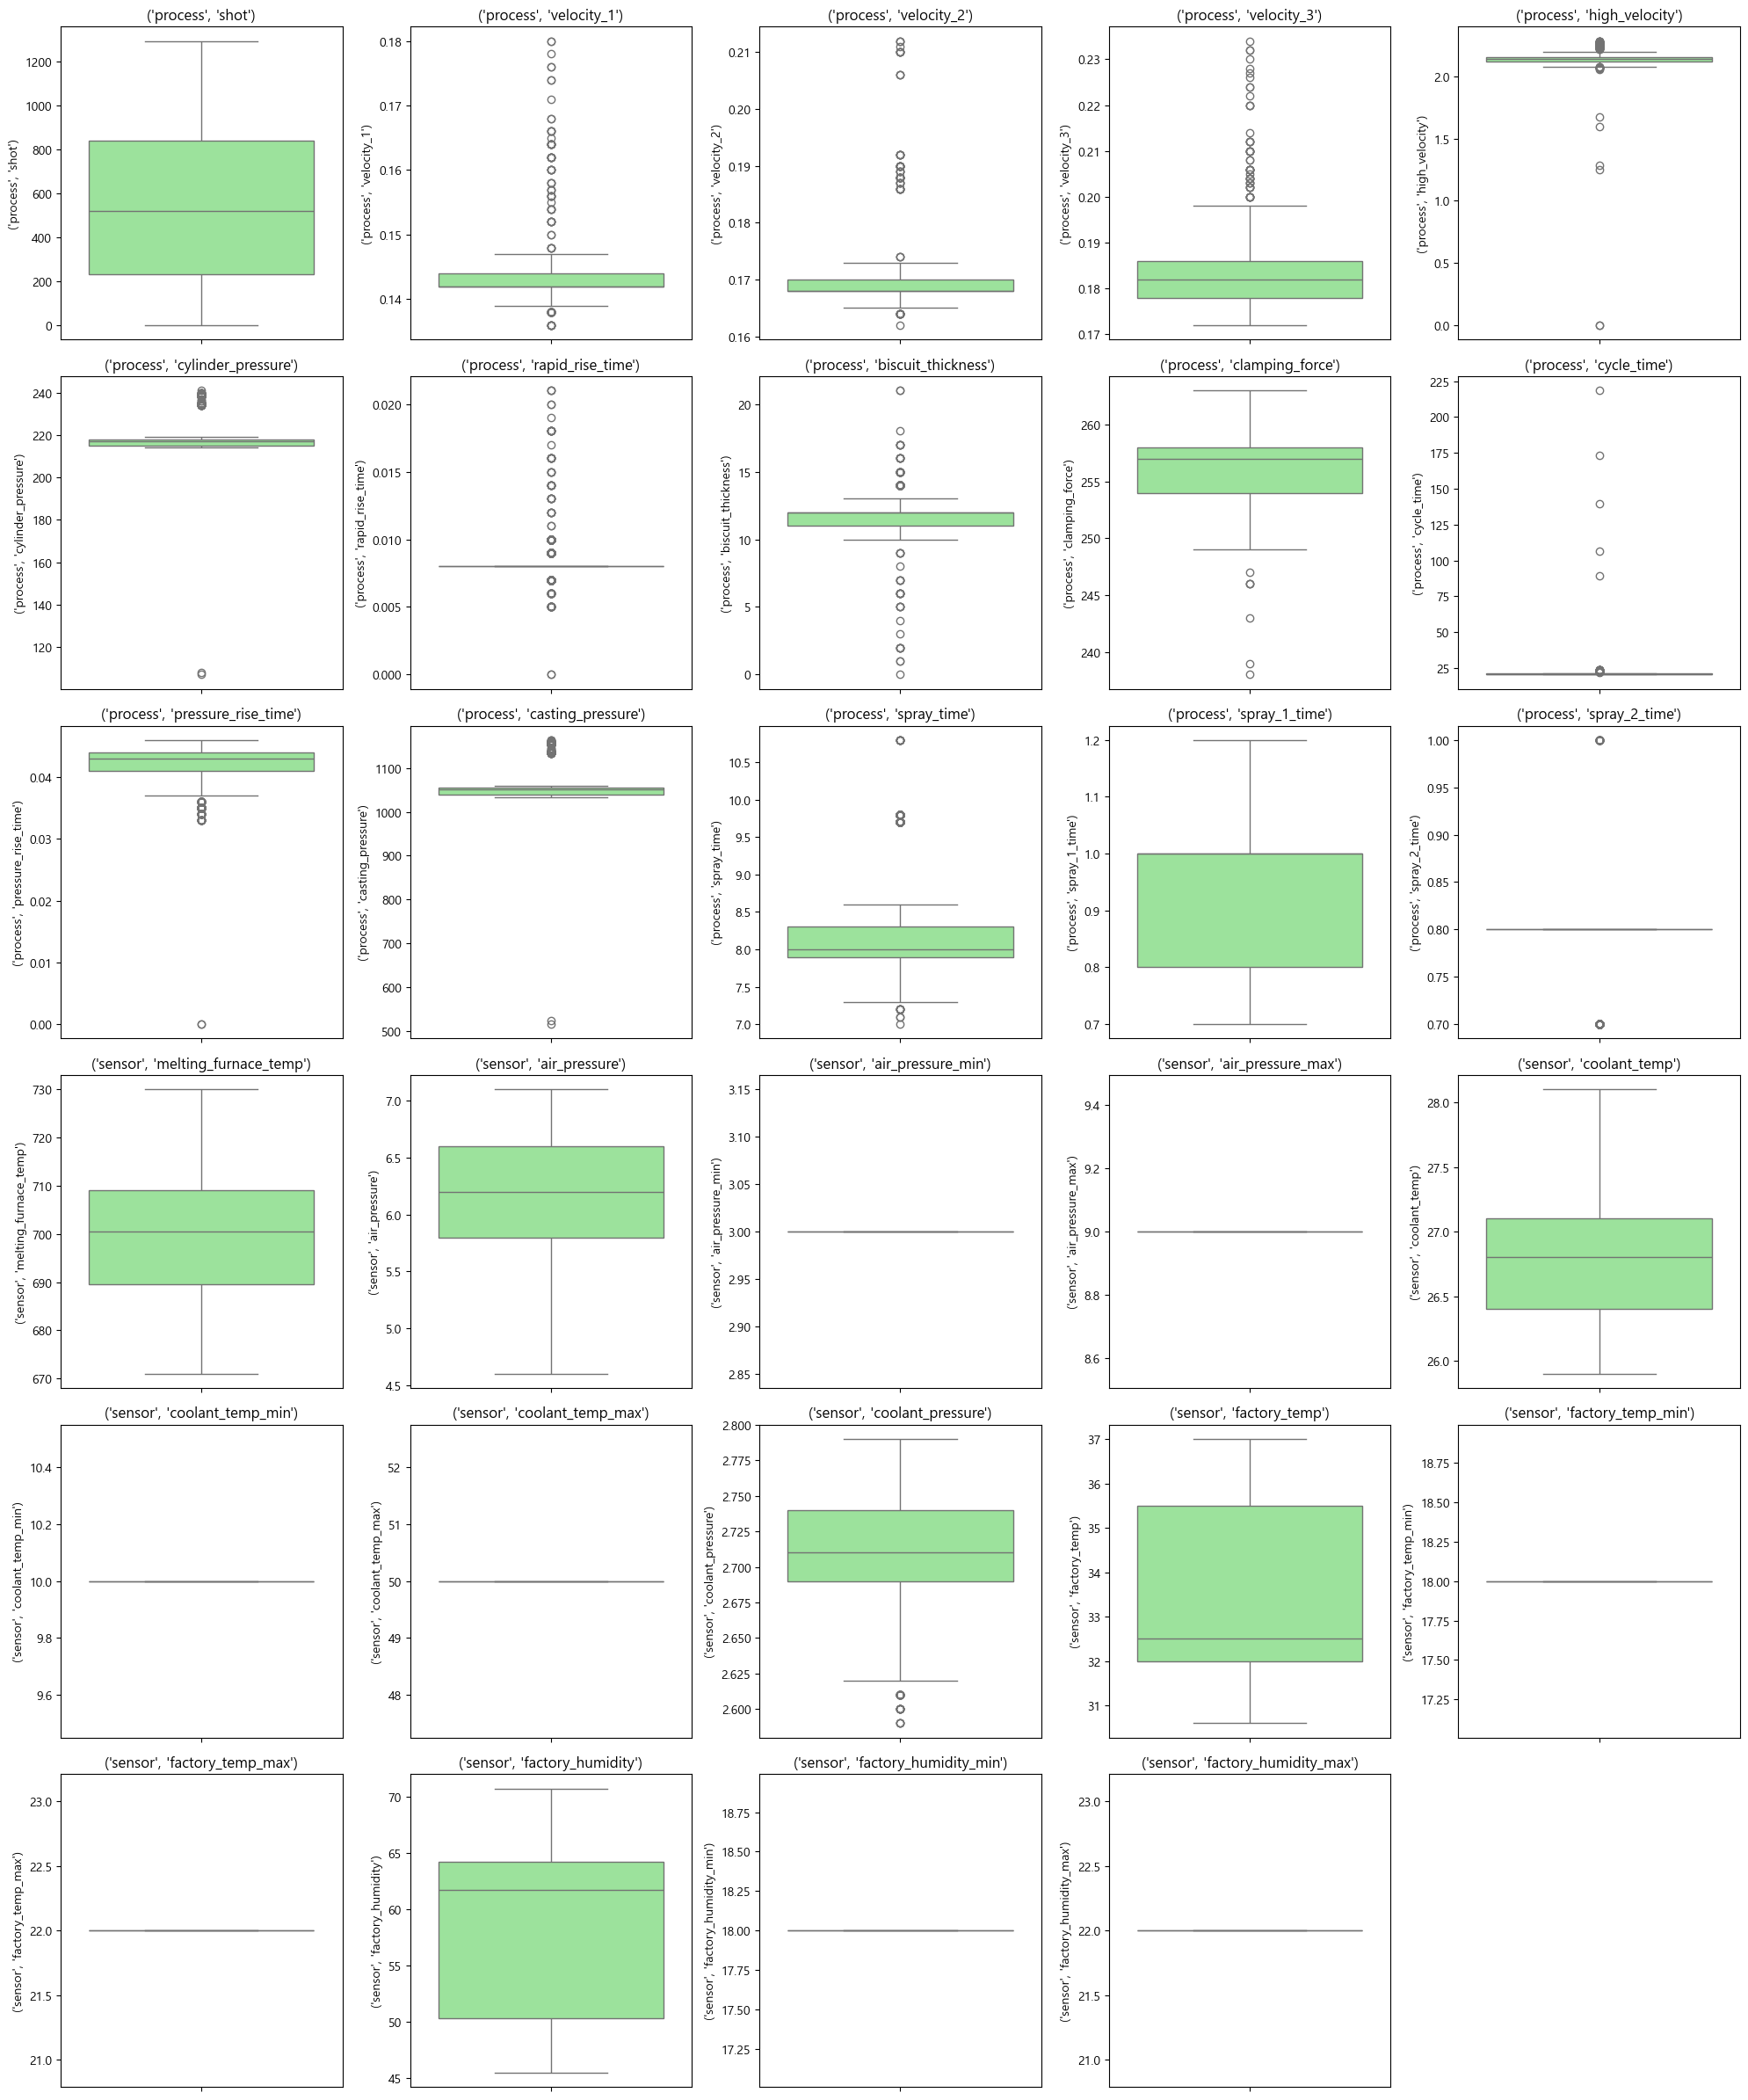

In [ ]:
# 박스플롯

cols = X_train.columns

n_cols = 5   # 한 행에 5개
n_rows = (len(cols) // n_cols) + 1

plt.figure(figsize=(20, 4*n_rows))

for i, col in enumerate(cols, 1):
    
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(y=X_train[col], color='lightgreen')
    plt.title(str(col))
    
plt.tight_layout()
plt.show()

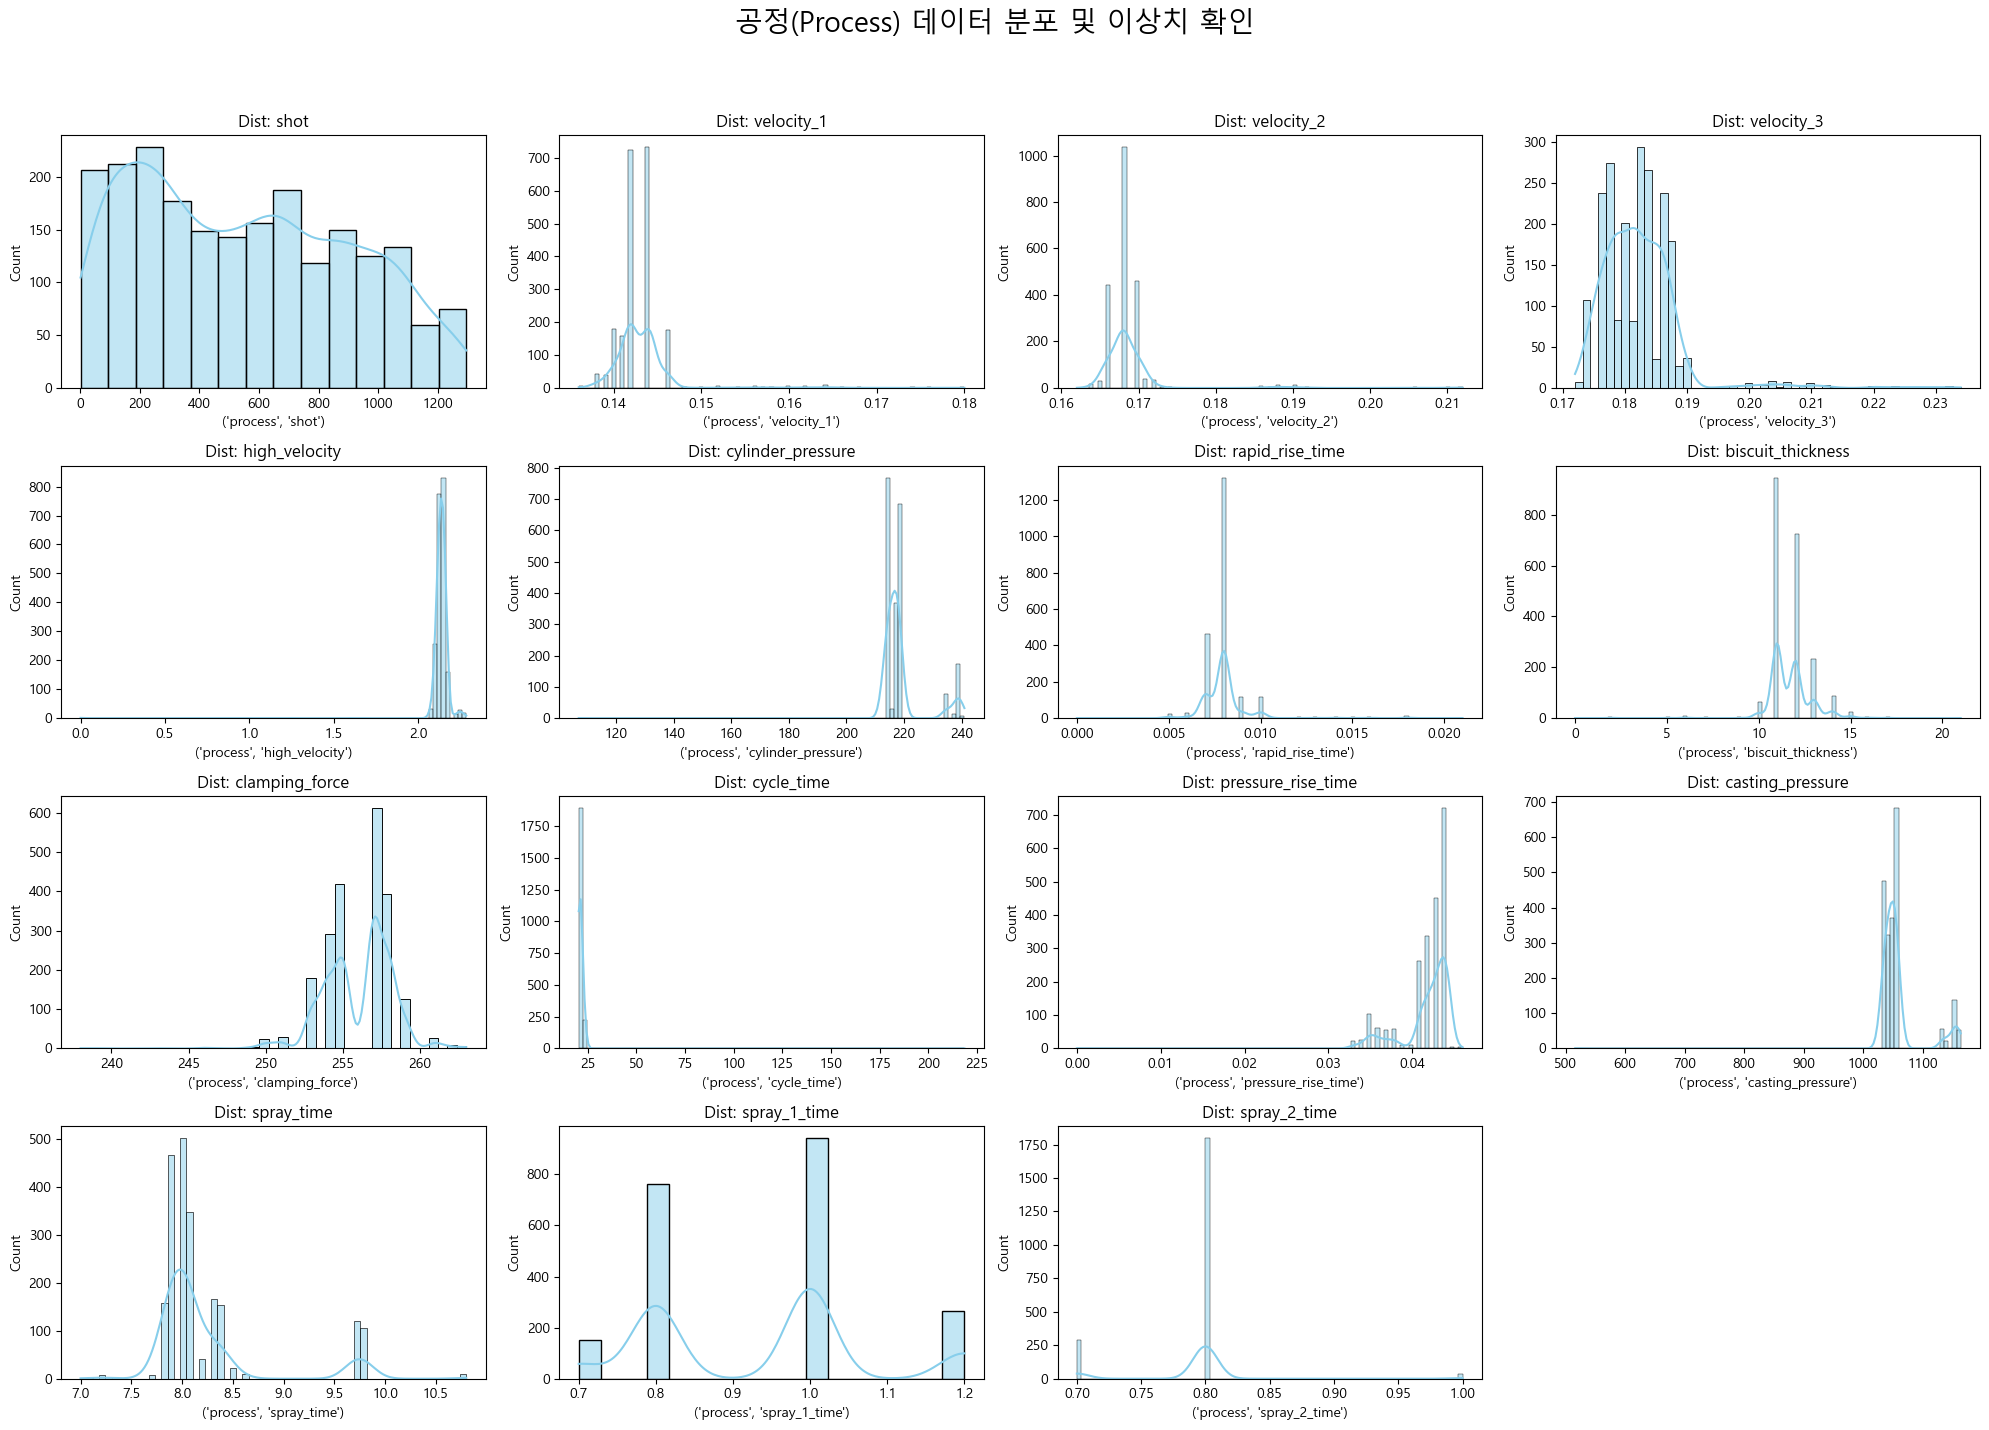

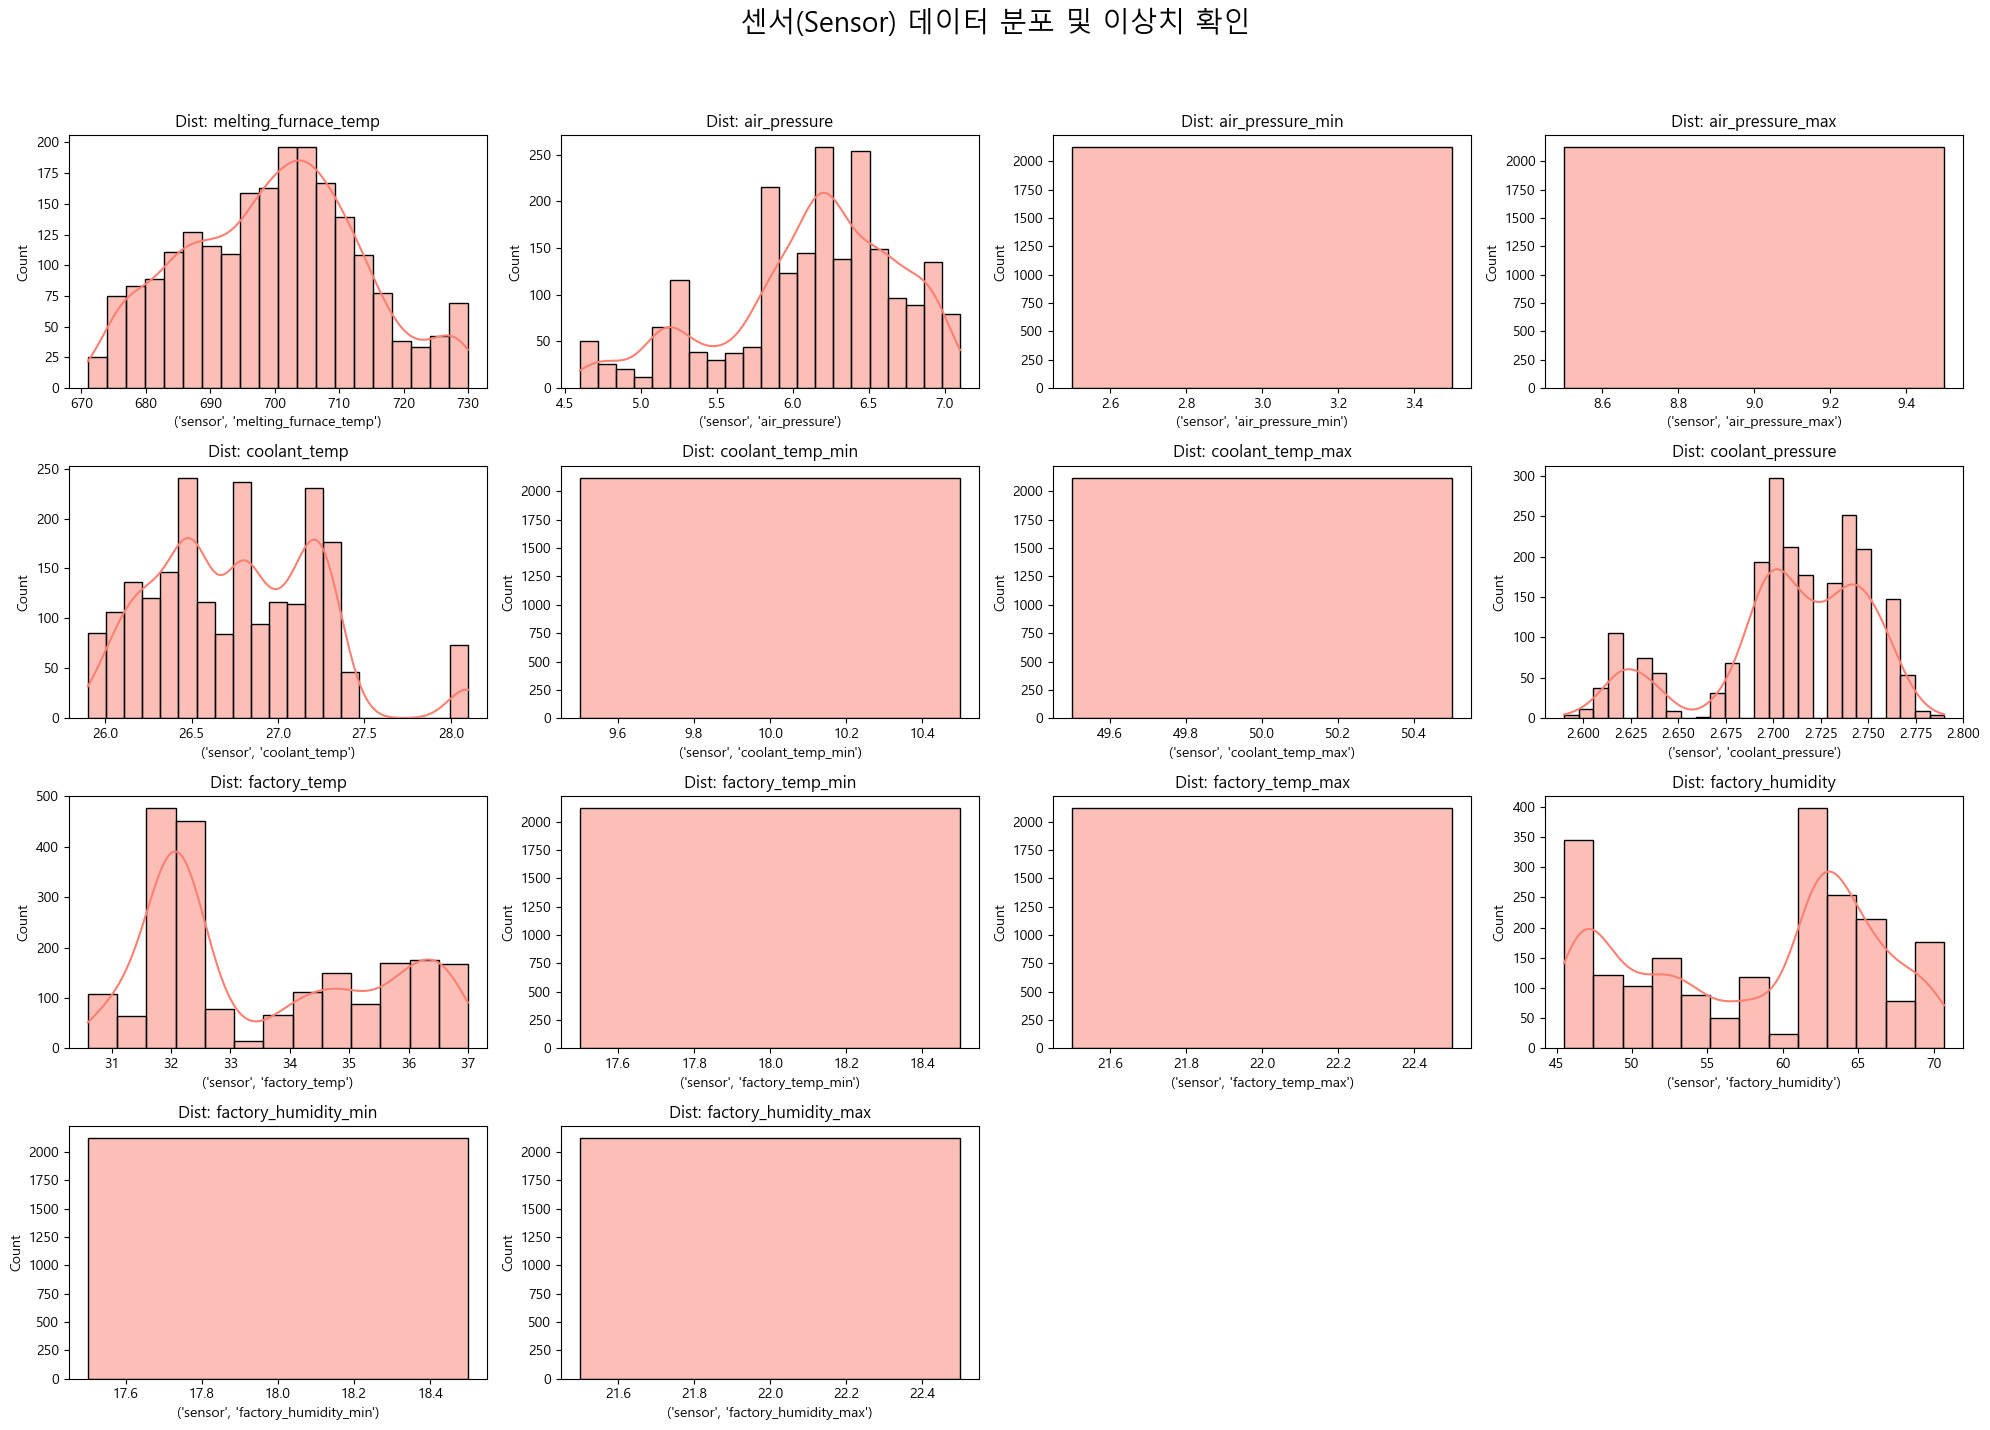

In [ ]:
# Process 관련 컬럼 히스토그램
process_cols = [col for col in X_train.columns if 'process' in str(col)]

plt.figure(figsize=(20, 15))
plt.suptitle("공정(Process) 데이터 분포 및 이상치 확인", fontsize=20)

for i, col in enumerate(process_cols, 1):
    plt.subplot(4, 4, i)
    sns.histplot(X_train[col], kde=True, color='skyblue')
    plt.title(f'Dist: {col[1]}') # MultiIndex의 하위 컬럼명 사용
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])

plt.show()

# Sensor 관련 컬럼 히스토그램
sensor_cols = [col for col in X_train.columns if 'sensor' in str(col)]

plt.figure(figsize=(20, 15))
plt.suptitle("센서(Sensor) 데이터 분포 및 이상치 확인", fontsize=20)

for i, col in enumerate(sensor_cols, 1):
    plt.subplot(4, 4, i)
    sns.histplot(X_train[col], kde=True, color='salmon')
    plt.title(f'Dist: {col[1]}')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])

plt.show()

#### feature 간 상관관계 - multicollinearity 확인

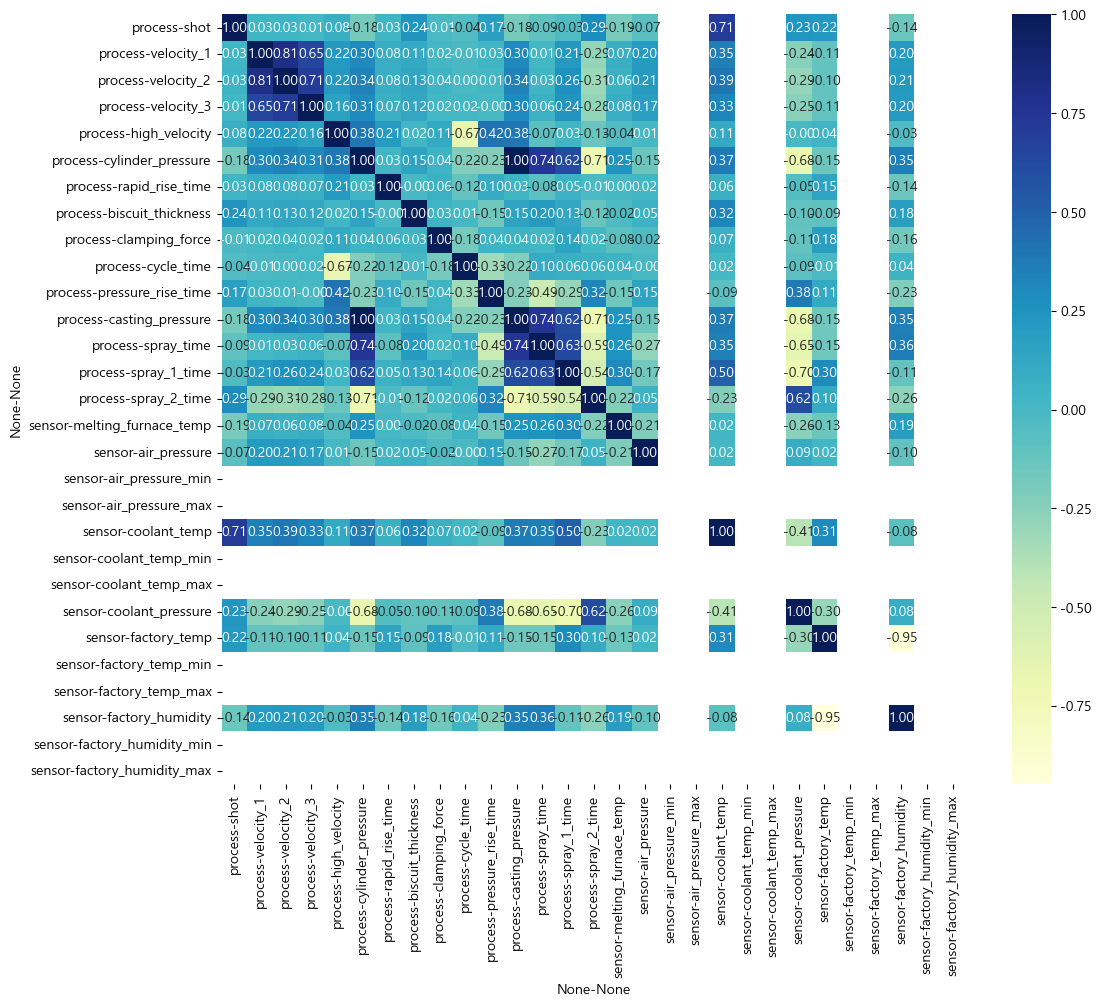

In [ ]:
corr = X_train.corr()

plt.figure(figsize=(12,10))

sns.heatmap(
    corr,
    cmap="YlGnBu",
    annot=True,      
    fmt=".2f"        
)

plt.show()

## y 타겟(불량) 분포 확인 

In [ ]:
y_train.value_counts(normalize=True)

(defect_flag, is_defect)
0    0.782752
1    0.217248
Name: proportion, dtype: float64

Class imbalance 확인


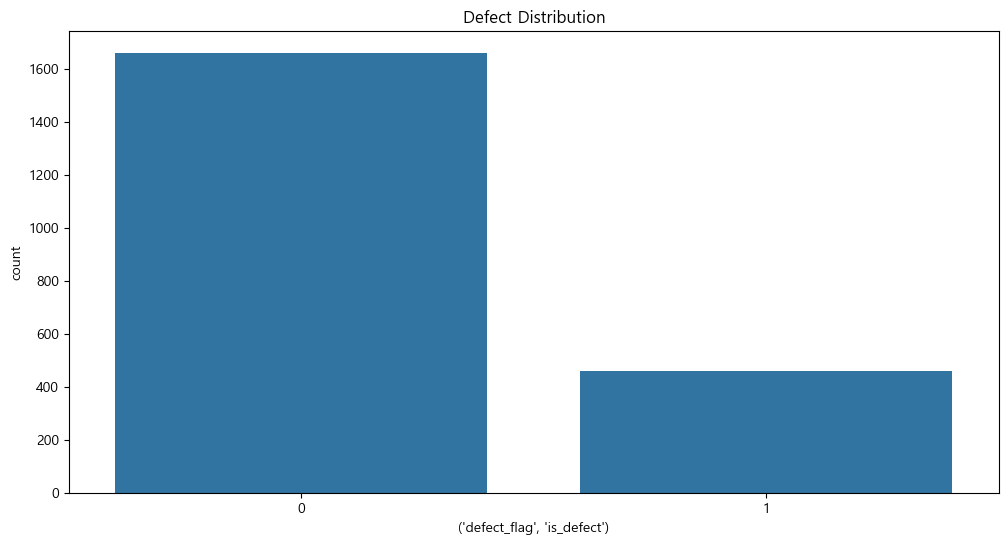

In [ ]:
# 정상 불량 분포 확인하기


print("="*60)
print("Class imbalance 확인")
print("="*60)

sns.countplot(x=y_train)
plt.title("Defect Distribution")
plt.show()



### 간단한 RandomForest로 중요 변수 확인해보기

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, random_state=42)

rf.fit(X_train, y_train)

import pandas as pd

importance = pd.Series(rf.feature_importances_, index=X_train.columns)
importance.sort_values(ascending=False).head(10)

process  shot                    0.123881
sensor   factory_humidity        0.100866
         melting_furnace_temp    0.079965
process  high_velocity           0.078562
sensor   factory_temp            0.063728
process  velocity_3              0.057602
sensor   coolant_pressure        0.052039
process  casting_pressure        0.051958
sensor   air_pressure            0.049623
process  velocity_1              0.044348
dtype: float64